In [ ]:
import zipfile
zip_ref = zipfile.ZipFile( '/content/archive.zip' , 'r')
zip_ref.extractall( '/content' )
zip_ref.close()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D, Flatten, Dropout, BatchNormalization
import matplotlib.pyplot as plt

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory  ( directory = '/content/train' ,
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size = (256, 256) )
validation_ds = keras.utils.image_dataset_from_directory( directory = '/content/test' ,
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256) )

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image, label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
# create CNN model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu' , input_shape=(256, 256,3)))
model.add(MaxPooling2D(pool_size= (2, 2) , strides=2, padding= 'valid'))

model.add(Conv2D(64, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu'))
model.add(MaxPooling2D(pool_size= (2, 2) , strides=2, padding= 'valid'))

model.add(Conv2D(128, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu'))
model.add(MaxPooling2D(pool_size= (2, 2) , strides=2 , padding= 'valid'))

model.add(Flatten())
model.add(Dense(128,activation= 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(1,activation= 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 83ms/step - accuracy: 0.5822 - loss: 0.6897 - val_accuracy: 0.7440 - val_loss: 0.5273
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7408 - loss: 0.5160 - val_accuracy: 0.7832 - val_loss: 0.4747
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.8231 - loss: 0.3919 - val_accuracy: 0.7766 - val_loss: 0.5989
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8942 - loss: 0.2575 - val_accuracy: 0.7798 - val_loss: 0.7259
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9438 - loss: 0.1414 - val_accuracy: 0.7816 - val_loss: 0.8769
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.9697 - loss: 0.0817 - val_accuracy: 0.7880 - val_loss: 0.9751
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9763 - loss: 0.0685 - val_accuracy: 0.7690 - val_loss: 1.1587
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9829 - loss: 0.0496 -

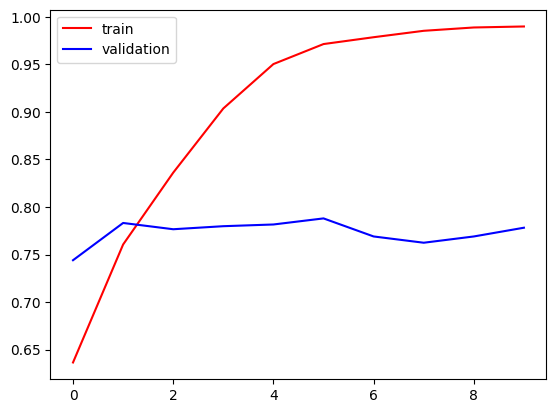

In [ ]:
import matplotlib. pyplot as plt
plt.plot(history.history['accuracy'],color= 'red', label='train')
plt.plot(history.history['val_accuracy'] ,color= 'blue', label= 'validation')
plt.legend( )
plt.show( )

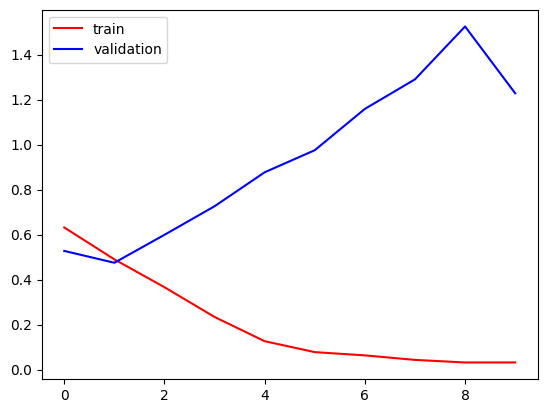

In [ ]:
plt.plot(history.history['loss'], color='red',label= 'train')
plt.plot (history. history['val_loss'] , color='blue', label= 'validation')
plt.legend( )
plt.show( )

## ways to reduce overfitting

* Add more data
* Data Augmentation
* LI/L2 Regularizer
* Dropout
* Batch Norm
* Reduce complexity

In [ ]:
# creating updated CNN model
model2 = Sequential()

model2.add(Conv2D(32, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu' , input_shape=(256, 256,3)))
model2.add(BatchNormalization( ) )
model2.add(MaxPooling2D(pool_size= (2, 2) , strides=2, padding= 'valid'))

model2.add(Conv2D(64, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu'))
model2.add (BatchNormalization( ) )
model2.add(MaxPooling2D(pool_size= (2, 2) , strides=2, padding= 'valid'))

model2.add(Conv2D(128, kernel_size=(3, 3) , padding= 'valid' ,activation= 'relu'))
model2.add (BatchNormalization( ) )
model2.add(MaxPooling2D(pool_size= (2, 2) , strides=2 , padding= 'valid'))

model2.add(Flatten())

model2.add(Dense(128,activation= 'relu'))
model2.add(Dropout(0.1))
model2.add(Dense(64, activation= 'relu'))
model2.add(Dropout(0.1))
model2.add(Dense(1,activation= 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history2 = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.7800 - val_loss: 1.4156
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9924 - loss: 0.0219 - val_accuracy: 0.7752 - val_loss: 1.4696
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9916 - loss: 0.0285 - val_accuracy: 0.7828 - val_loss: 1.3808
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9933 - loss: 0.0190 - val_accuracy: 0.7722 - val_loss: 1.4039
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.7864 - val_loss: 1.3646
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9950 - loss: 0.0148 - val_accuracy: 0.7808 - val_loss: 1.5382
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.7728 - val_loss: 1.4732
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.9951 - loss: 0.0173 - 

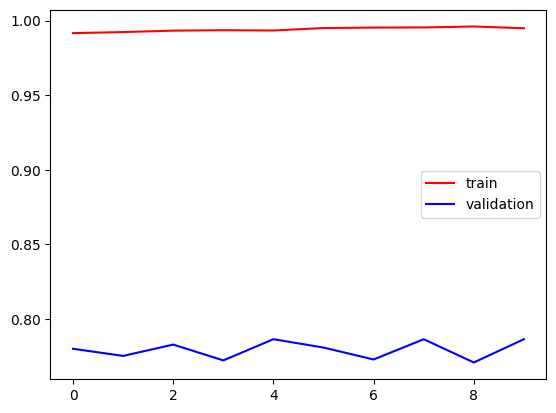

In [ ]:
plt.plot(history2.history['accuracy'],color= 'red', label='train')
plt.plot(history2.history['val_accuracy'] ,color= 'blue', label= 'validation')
plt.legend( )
plt.show( )

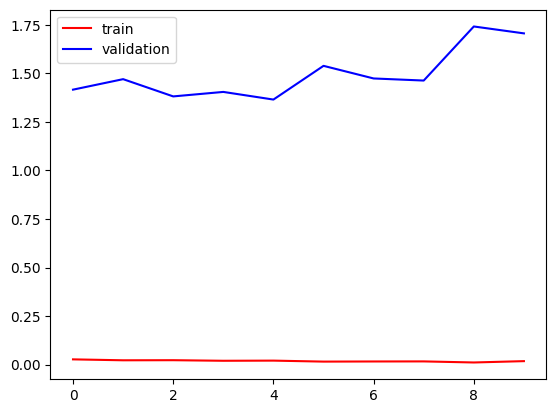

In [ ]:
plt.plot(history2.history['loss'], color='red',label= 'train')
plt.plot (history2.history['val_loss'] , color='blue', label= 'validation')
plt.legend( )
plt.show( )

In [ ]:
import cv2

In [ ]:
test_img_dog= cv2.imread('/content/Dog_cnn.png')

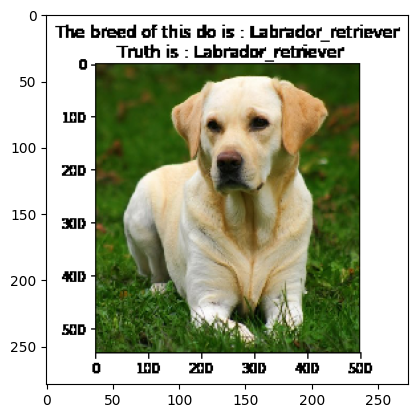

In [ ]:
plt.imshow(test_img_dog)

In [ ]:
test_img_dog.shape

(279, 273, 3)

In [ ]:
test_img_dog = cv2.resize(test_img_dog,(256,256))

In [ ]:
test_input = test_img_dog.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[1.]], dtype=float32)

DOG = 1

CAT = 0

In [ ]:
test_img_cat= cv2.imread('/content/Cat_cnn.png')

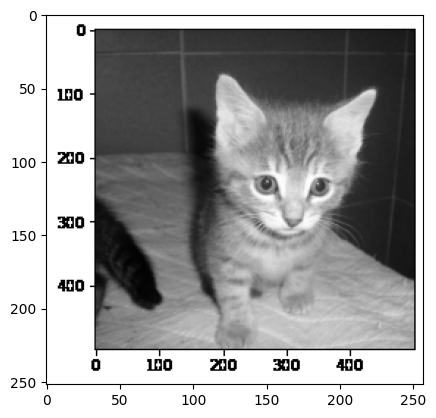

In [ ]:
plt.imshow(test_img_cat)

In [ ]:
test_img_cat.shape

(252, 257, 3)

In [ ]:
test_img_cat = cv2.resize(test_img_cat,(256,256))

In [ ]:
test_input = test_img_cat.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[0.]], dtype=float32)

DOG = 1

CAT = 0